Saving RTA Dataset.csv to RTA Dataset.csv
Shape: (2889, 32)
Columns: ['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']
<class 'pandas.core.frame.DataFrame'>
Index: 2889 entries, 8 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                      

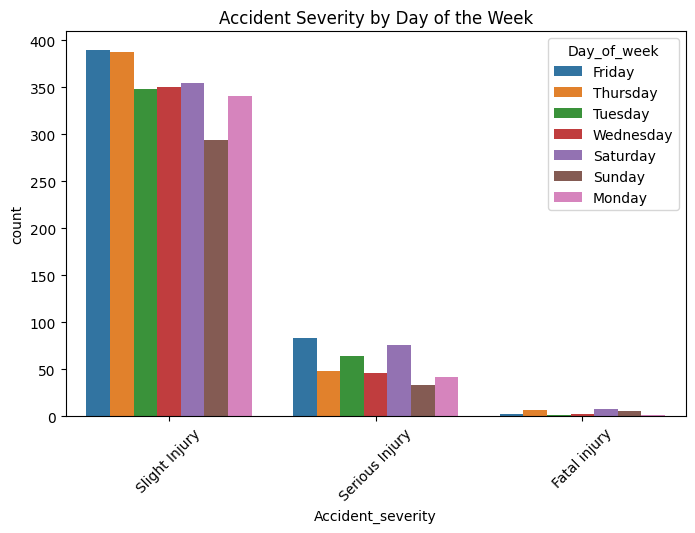

                precision    recall  f1-score   support

Serious Injury       0.25      0.12      0.16        75
 Slight Injury       0.88      0.95      0.91       503

      accuracy                           0.84       578
     macro avg       0.56      0.53      0.54       578
  weighted avg       0.80      0.84      0.81       578

🚦 Predicted Accident Severity: Serious Injury


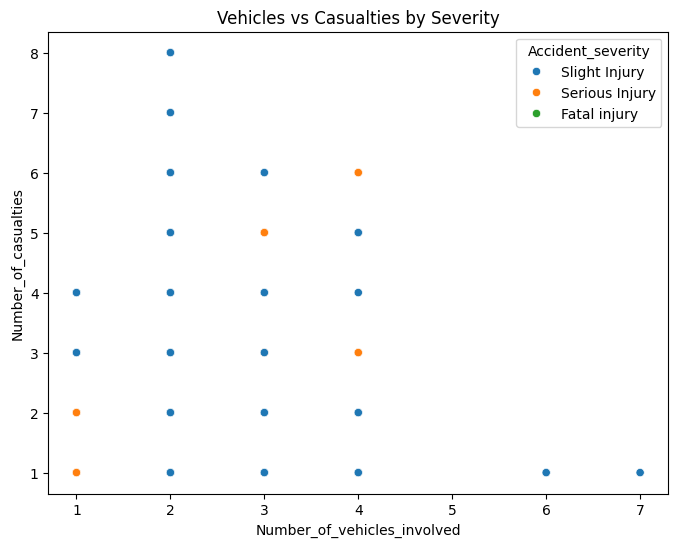

In [3]:
# 📁 Step 1: Upload RTA Dataset
from google.colab import files
uploaded = files.upload()

import pandas as pd

# Load dataset
df = pd.read_csv("RTA Dataset.csv")
df.dropna(inplace=True)
df.head()
# 📊 Step 2: Data Exploration
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.info()
df.describe()
# 📈 Step 3: Visualize Accident Severity
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Accident_severity', hue='Day_of_week')
plt.title("Accident Severity by Day of the Week")
plt.xticks(rotation=45)
plt.show()
# 🧠 Step 4: Encode & Train the Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Define features and target
features = ['Number_of_vehicles_involved', 'Number_of_casualties',
            'Day_of_week', 'Age_band_of_driver', 'Type_of_vehicle',
            'Area_accident_occured', 'Road_surface_type']
target = 'Accident_severity'

# Encode categorical data
df_encoded = pd.get_dummies(df[features + [target]], drop_first=True)

# Define X and y
X = df_encoded.drop(columns=[col for col in df_encoded.columns if col.startswith(f"{target}_")])
y_cols = [col for col in df_encoded.columns if col.startswith(f"{target}_")]
y = df_encoded[y_cols].idxmax(axis=1).str.replace(f"{target}_", "") if y_cols else df[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
# 🔮 Step 5: Make a Prediction from User Input
sample_input = {
    'Number_of_vehicles_involved': 2,
    'Number_of_casualties': 1,
    'Day_of_week': 'Friday',
    'Age_band_of_driver': '31-50',
    'Type_of_vehicle': 'Automobile',
    'Area_accident_occured': 'Residential areas',
    'Road_surface_type': 'Asphalt roads'
}

# Convert to DataFrame
input_df = pd.DataFrame([sample_input])
input_encoded = pd.get_dummies(input_df)
input_encoded = input_encoded.reindex(columns=X.columns, fill_value=0)

# Predict
prediction = model.predict(input_encoded)[0]
print("🚦 Predicted Accident Severity:", prediction)
# 📊 Step 6: Additional Visualization - Vehicles vs Casualties
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Number_of_vehicles_involved", y="Number_of_casualties", hue="Accident_severity")
plt.title("Vehicles vs Casualties by Severity")
plt.show()